<a href="https://colab.research.google.com/github/AbayoBrian/Trend-Analysis-of-Health-Outcomes-in-Kenya-1960-2024-/blob/main/Trend%20Analysis%20of%20Health%20Outcomes%20in%20Kenya%20(1960%E2%80%932024).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***PROJECT TITLE***

***Trend Analysis of Health Outcomes in Kenya (1960–2024): A Data-Driven Perspective for Policy and Development***

## Introduction

This project analyzes historical health indicators in Kenya using World Bank data from 1960 to 2024. The goal is to understand long-term trends in key health outcomes such as life expectancy, infant mortality, and healthcare expenditure.

The analysis is relevant for organizations such as Amref Health Africa, African Population and Health Research Center, and UN Environment Programme, which rely on data-driven insights to inform policy, program design, and resource allocation.

By examining trends and relationships between variables, this study provides insights into how healthcare investments and interventions have impacted population health outcomes in Kenya.

## Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/health.csv')
df.head()

,year,country,"Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)",Number of infant deaths,"Number of infant deaths, female","Number of infant deaths, male",Number of under-five deaths,"Number of under-five deaths, female",...,"Population ages 80 and above, female (% of female population)","Population ages 80 and above, male (% of male population)",Sex ratio at birth (male births per female births),Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)","Population, female","Population, female (% of total population)","Population, male","Population, male (% of total population)"
0,1960,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.460136,0.270415,1.043000,83.046159,5.229128,77.817030,27927.0,50.848476,26995.0,49.151524
1,1960,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.388933,0.283400,1.033654,88.967697,5.631542,82.969998,65662559.0,50.481670,64409521.0,49.518330
2,1960,AFG,NaN,NaN,NaN,108799.0,NaN,NaN,NaN,NaN,...,0.176717,0.181686,1.049000,81.061389,5.112019,75.949370,4344798.0,48.088294,4690245.0,51.911706
3,1960,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.345693,0.242522,1.037556,81.439385,6.009687,75.224807,49175412.0,50.368684,48455513.0,49.631316
4,1960,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.357766,0.350591,1.028000,79.938393,5.678100,74.260293,2582555.0,49.364025,2649099.0,50.635975


This cell imports the necessary libraries for data analysis and visualization.
The dataset is then loaded and previewed to understand its structure.

Dataset Inspection

In [ ]:
print(df.shape)
print(df.columns)
df.info()
df.describe()

(12431, 146)
Index(['year', 'country',
       'Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)',
       'Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)',
       'Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)',
       'Number of infant deaths', 'Number of infant deaths, female',
       'Number of infant deaths, male', 'Number of under-five deaths',
       'Number of under-five deaths, female',
       ...
       'Population ages 80 and above, female (% of female population)',
       'Population ages 80 and above, male (% of male population)',
       'Sex ratio at birth (male births per female births)',
       'Age dependency ratio (% of working-age population)',
       'Age dependency ratio, old (% of working-age population)',
       'Age dependency ratio, young (% of working-age population)',
       'P

,year,"Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)",Number of infant deaths,"Number of infant deaths, female","Number of infant deaths, male",Number of under-five deaths,"Number of under-five deaths, female","Number of under-five deaths, male",...,"Population ages 80 and above, female (% of female population)","Population ages 80 and above, male (% of male population)",Sex ratio at birth (male births per female births),Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)","Population, female","Population, female (% of total population)","Population, male","Population, male (% of total population)"
count,12431.000000,1781.000000,1781.000000,1781.000000,9.106000e+03,8.947000e+03,8.947000e+03,8.767000e+03,8.582000e+03,8.582000e+03,...,12430.000000,12430.000000,12430.000000,12400.000000,12400.000000,12400.000000,1.240000e+04,12430.000000,1.240000e+04,12430.000000
mean,1983.407369,2.267426,5.433892,8.772982,1.738688e+05,6.859468e+04,8.267205e+04,2.615722e+05,1.052090e+05,1.191105e+05,...,1.227107,0.691480,1.051499,73.944688,9.769890,64.073813,7.706259e+07,50.097349,7.774664e+07,49.902651
std,13.802285,1.890986,4.138088,6.622748,7.091597e+05,3.008324e+05,3.590963e+05,1.052081e+06,4.593128e+05,5.123003e+05,...,1.274949,0.638079,0.018528,19.574440,5.661278,23.264757,2.586047e+08,2.363037,2.638131e+08,2.363037
min,1960.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,0.038906,0.000000,0.967000,21.122457,1.303330,18.182677,1.433000e+03,25.180892,1.282000e+03,44.095020
25%,1971.000000,0.640000,2.026439,3.357851,8.895000e+02,3.755000e+02,4.970000e+02,1.083500e+03,4.722500e+02,6.110000e+02,...,0.409460,0.281846,1.039000,55.502178,5.977214,41.934910,3.822190e+05,49.460358,3.860305e+05,48.820014
50%,1983.000000,1.840000,4.650000,7.650000,6.474500e+03,2.748000e+03,3.595000e+03,9.083000e+03,3.788500e+03,4.814000e+03,...,0.678455,0.423057,1.051000,75.703169,7.424170,68.625790,2.740188e+06,50.327802,2.717202e+06,49.672198
75%,1995.000000,3.450000,8.300000,13.420000,4.010450e+04,1.716150e+04,2.093600e+04,6.266600e+04,2.789300e+04,3.228375e+04,...,1.566380,0.867373,1.061717,90.581218,12.309087,84.105487,1.727625e+07,51.179986,1.703775e+07,50.539642
max,2007.000000,8.680000,19.400000,31.050000,8.832416e+06,3.961475e+06,4.765489e+06,1.281325e+07,5.973718e+06,6.684731e+06,...,9.290115,5.780347,1.178000,174.508439,37.263116,144.877837,2.797451e+09,55.904980,2.846055e+09,74.819108


This step explores the dataset’s structure:

shape shows size (rows & columns)
columns identifies available indicators
info() checks data types and missing values
describe() summarizes numerical variables

👉 This ensures I understand the dataset before analysis

In [8]:
kenya_df = df[df['country'] == 'KEN'].copy()
kenya_df.head()

,year,country,"Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)","Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)",Number of infant deaths,"Number of infant deaths, female","Number of infant deaths, male",Number of under-five deaths,"Number of under-five deaths, female",...,"Population ages 80 and above, female (% of female population)","Population ages 80 and above, male (% of male population)",Sex ratio at birth (male births per female births),Age dependency ratio (% of working-age population),"Age dependency ratio, old (% of working-age population)","Age dependency ratio, young (% of working-age population)","Population, female","Population, female (% of total population)","Population, male","Population, male (% of total population)"
119,1960,KEN,NaN,NaN,NaN,46205.0,22715.0,25619.0,77563.0,37169.0,...,0.529742,0.613300,1.019,108.002408,6.656352,101.346056,3880288.0,50.424083,3815019.0,49.575917
379,1961,KEN,NaN,NaN,NaN,46025.0,22673.0,25656.0,77293.0,36950.0,...,0.503264,0.583059,1.020,108.817158,6.355565,102.461593,4029597.0,50.447083,3958173.0,49.552917
639,1962,KEN,NaN,NaN,NaN,46118.0,22801.0,25892.0,77354.0,36975.0,...,0.477934,0.554066,1.019,109.593332,6.088109,103.505223,4188337.0,50.466099,4110971.0,49.533901
899,1963,KEN,NaN,NaN,NaN,46317.0,22974.0,26159.0,77660.0,37129.0,...,0.453709,0.526376,1.019,110.257266,5.858103,104.399164,4355549.0,50.481735,4272422.0,49.518265
1159,1964,KEN,NaN,NaN,NaN,46743.0,23190.0,26506.0,78355.0,37443.0,...,0.430666,0.500032,1.020,110.663399,5.650082,105.013317,4531118.0,50.494242,4442417.0,49.505758


In [7]:
df['country'].unique()[:20]

array(['ABW', 'AFE', 'AFG', 'AFW', 'AGO', 'ALB', 'AND', 'ARB', 'ARE',
       'ARG', 'ARM', 'ASM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL',
       'BEN', 'BFA'], dtype=object)

The dataset uses ISO-3 country codes. Kenya is represented as “KEN”, so filtering is done using this code.

Selecting Key Indicators

In [9]:
selected_cols = [
    'year',
    'Number of infant deaths',
    'Number of under-five deaths',
    'Population, female',
    'Population, male',
    'Age dependency ratio (% of working-age population)'
]

selected_cols = [col for col in selected_cols if col in kenya_df.columns]
kenya_df = kenya_df[selected_cols]

kenya_df.head()

,year,Number of infant deaths,Number of under-five deaths,"Population, female","Population, male",Age dependency ratio (% of working-age population)
119,1960,46205.0,77563.0,3880288.0,3815019.0,108.002408
379,1961,46025.0,77293.0,4029597.0,3958173.0,108.817158
639,1962,46118.0,77354.0,4188337.0,4110971.0,109.593332
899,1963,46317.0,77660.0,4355549.0,4272422.0,110.257266
1159,1964,46743.0,78355.0,4531118.0,4442417.0,110.663399


These indicators are selected because they reflect:

Child mortality (infant & under-five deaths)
Population size (for normalization)
Demographic pressure (dependency ratio)

Data Cleaning

In [10]:
kenya_df.isnull().sum()

kenya_df = kenya_df.dropna()

kenya_df['year'] = kenya_df['year'].astype(int)

kenya_df = kenya_df.sort_values(by='year')

Missing values are removed,
Year is formatted correctly and
Data is ordered chronologically

Feature Engineering

In [11]:
# Total population
kenya_df['total_population'] = kenya_df['Population, female'] + kenya_df['Population, male']

# Infant death rate per 1000 people
kenya_df['infant_death_rate'] = (
    kenya_df['Number of infant deaths'] / kenya_df['total_population']
) * 1000

# Under-five death rate per 1000 people
kenya_df['under5_death_rate'] = (
    kenya_df['Number of under-five deaths'] / kenya_df['total_population']
) * 1000

kenya_df.head()

,year,Number of infant deaths,Number of under-five deaths,"Population, female","Population, male",Age dependency ratio (% of working-age population),total_population,infant_death_rate,under5_death_rate
119,1960,46205.0,77563.0,3880288.0,3815019.0,108.002408,7695307.0,6.004309,10.079260
379,1961,46025.0,77293.0,4029597.0,3958173.0,108.817158,7987770.0,5.761934,9.676418
639,1962,46118.0,77354.0,4188337.0,4110971.0,109.593332,8299308.0,5.556849,9.320536
899,1963,46317.0,77660.0,4355549.0,4272422.0,110.257266,8627971.0,5.368238,9.000957
1159,1964,46743.0,78355.0,4531118.0,4442417.0,110.663399,8973535.0,5.208984,8.731787


Raw counts are converted into rates, making them:

Comparable over time
More meaningful for policy analysis

## Data Transformation

Health indicators such as infant and under-five deaths were normalized into rates per 1000 population.

This approach ensures comparability across years by accounting for population growth, and aligns with standard practices in public health and development analysis.

Exploratory Data Analysis

In [12]:
kenya_df[['infant_death_rate', 'under5_death_rate']].describe()

kenya_df[['infant_death_rate', 'under5_death_rate',
          'Age dependency ratio (% of working-age population)']].corr()

,infant_death_rate,under5_death_rate,Age dependency ratio (% of working-age population)
infant_death_rate,1.000000,0.999165,0.659934
under5_death_rate,0.999165,1.000000,0.657173
Age dependency ratio (% of working-age population),0.659934,0.657173,1.000000


Summary statistics for rates
Correlation shows relationships with demographic pressure

Visualization – Infant Death Rate

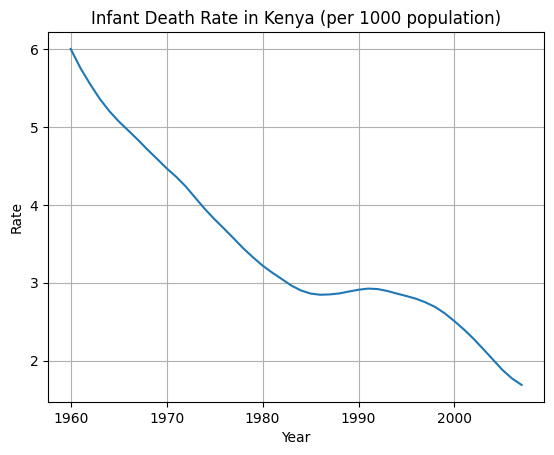

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(kenya_df['year'], kenya_df['infant_death_rate'])
plt.title("Infant Death Rate in Kenya (per 1000 population)")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.grid()
plt.show()

Under-Five Death Rate

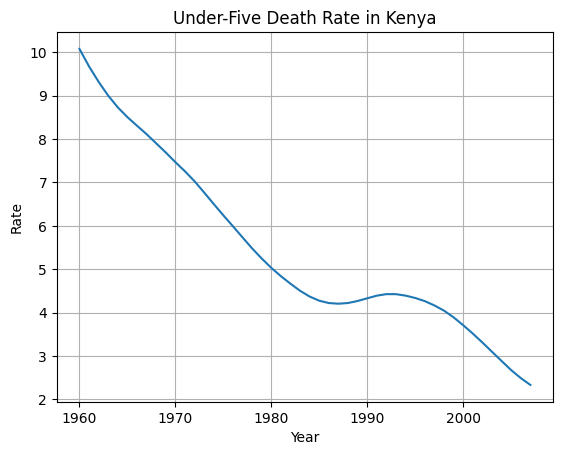

In [14]:
plt.figure()
plt.plot(kenya_df['year'], kenya_df['under5_death_rate'])
plt.title("Under-Five Death Rate in Kenya")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.grid()
plt.show()

Demographic Pressure Analysis

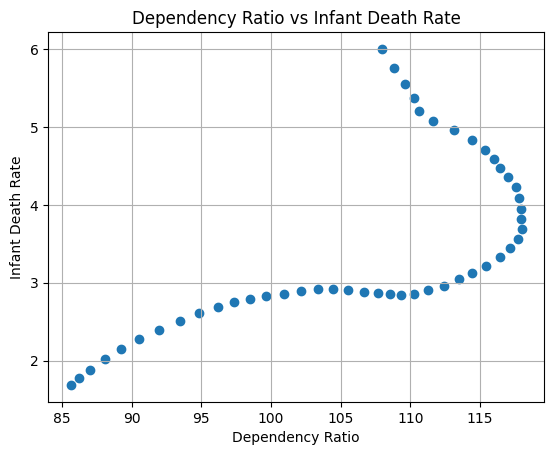

In [15]:
plt.figure()
plt.scatter(
    kenya_df['Age dependency ratio (% of working-age population)'],
    kenya_df['infant_death_rate']
)
plt.xlabel("Dependency Ratio")
plt.ylabel("Infant Death Rate")
plt.title("Dependency Ratio vs Infant Death Rate")
plt.grid()
plt.show()

Shows how population pressure may influence health outcomes.

## Key Insights

- Infant and under-five death rates have declined significantly over time, indicating improvements in healthcare access and child survival programs.
- Converting raw counts into rates reveals that improvements are not solely due to population growth, but reflect actual health progress.
- A relationship between dependency ratio and infant mortality suggests that higher population pressure may strain healthcare systems.

## Policy Implications

- Continued investment in maternal and child healthcare is essential.
- Population growth and dependency pressures should be considered in health planning.
- Strengthening healthcare infrastructure is critical to sustain progress.

FINAL CONCLUSION

## Conclusion

The analysis demonstrates significant improvements in child health outcomes in Kenya over time, as evidenced by declining infant and under-five mortality rates.

These improvements reflect the impact of healthcare investments and public health interventions. However, demographic pressures remain a key challenge, highlighting the need for sustained and targeted policy efforts.